In [3]:
!pip install imbalanced-learn

### Knižnice ###

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import AdaBoostClassifier

### Data ###

In [8]:
#Načítanie dát zo súboru
df = pd.read_csv("data.csv")

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

#Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight_value:.2f}\n")


print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("base_scale_pos_weight:", scale_pos_weight_value)

scale_pos_weight = 29.99

Shape X_train: (5455, 95)
Shape X_test: (1364, 95)
base_scale_pos_weight: 29.994318181818183


### AdaBoost Baseline ###

Baseline AdaBoost
              precision    recall  f1-score   support

           0     0.9754    0.9902    0.9827      1320
           1     0.4583    0.2500    0.3235        44

    accuracy                         0.9663      1364
   macro avg     0.7169    0.6201    0.6531      1364
weighted avg     0.9587    0.9663    0.9614      1364



<Figure size 600x500 with 0 Axes>

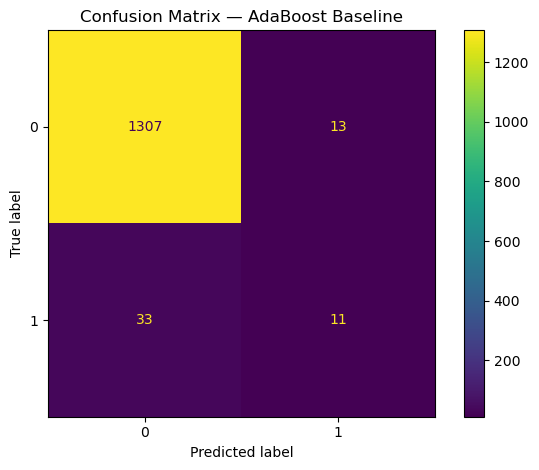

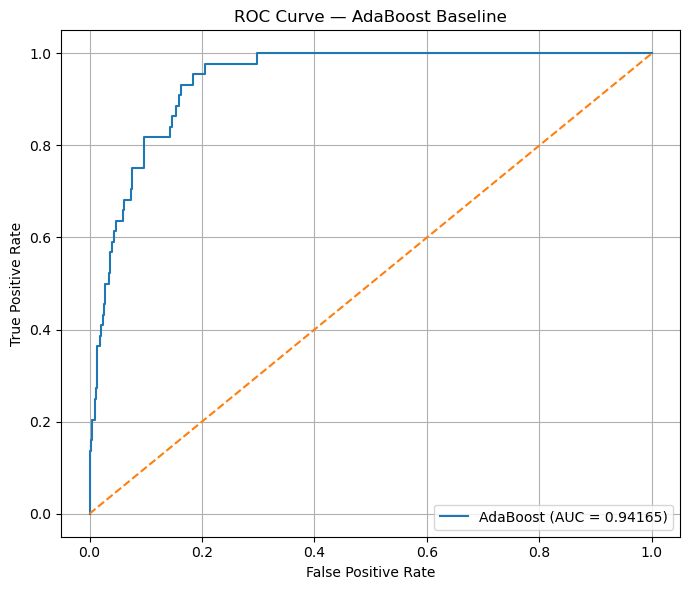

ROC AUC: 0.94165


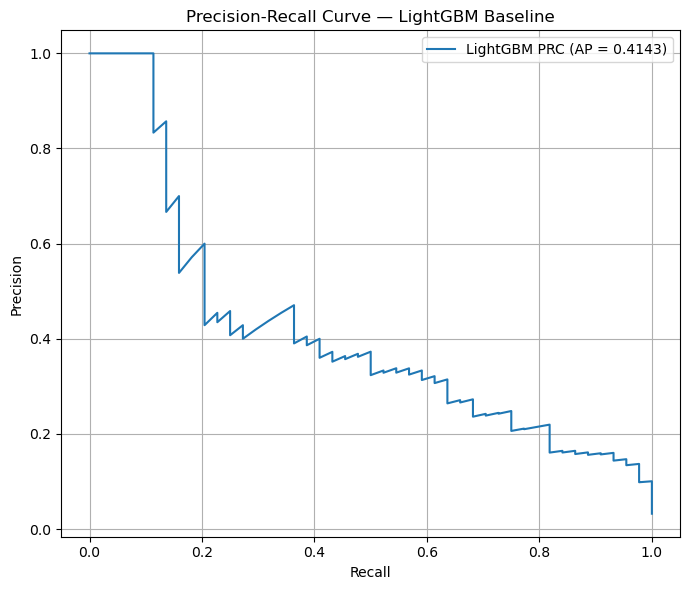

PRC AUC (Average Precision): 0.4143


In [24]:
#Vytvorenie základného AdaBoost modelu s váhou pre nevyvážené triedy
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred1 = ada.predict(X_test)
y_proba1 = ada.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Baseline AdaBoost")
print(classification_report(y_test, y_pred1, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — AdaBoost Baseline")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc1 = roc_auc_score(y_test, y_proba1)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc1:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AdaBoost Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc1:.5f}")

#Precision-Recall krivka
precisions_ada1, recalls_ada1, _ = precision_recall_curve(y_test, y_proba1)
prc_auc_ada1 = average_precision_score(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(recalls_ada1, precisions_ada1, label=f"LightGBM PRC (AP = {prc_auc_ada1:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — LightGBM Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc_ada1:.4f}")


### Baseline AdaBoost + SMOTE ###

Baseline AdaBoost + SMOTE
              precision    recall  f1-score   support

           0    0.99188   0.92500   0.95727      1320
           1    0.25564   0.77273   0.38418        44

    accuracy                        0.92009      1364
   macro avg    0.62376   0.84886   0.67073      1364
weighted avg    0.96813   0.92009   0.93878      1364


Confusion Matrix
[[1221   99]
 [  10   34]]


<Figure size 600x500 with 0 Axes>

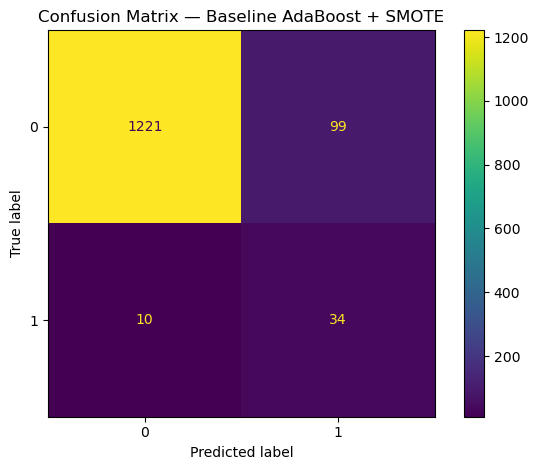

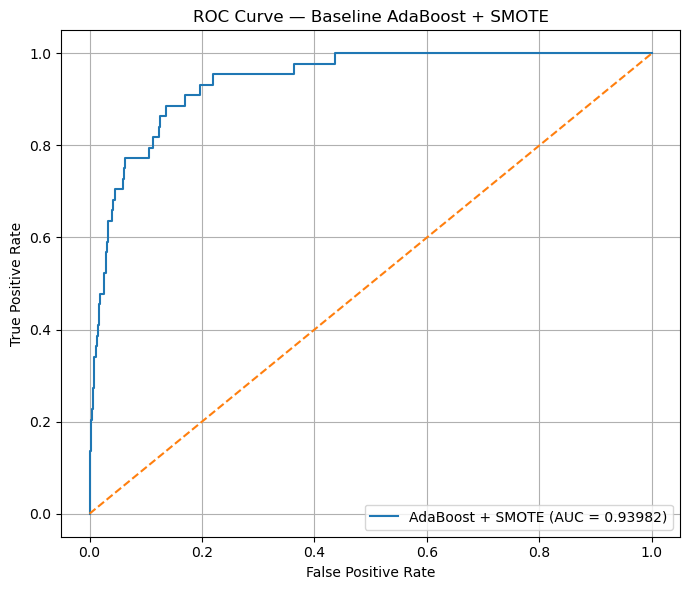

ROC AUC: 0.93982


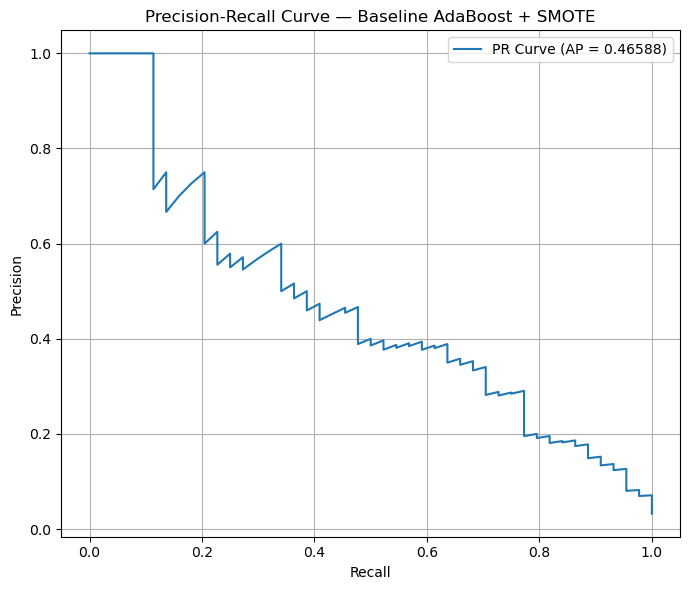

PRC AUC (Average Precision): 0.46588


In [28]:
#Vytvorenie pipeline so SMOTE a AdaBoost modelom
baseline_smote_ada = ImbPipeline(steps=[
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.1,
            random_state=42
        )
    )
])

#Trénovanie pipeline na trénovacích dátach
baseline_smote_ada.fit(X_train, y_train)

#Trénovanie pipeline na trénovacích dátach
y_pred2 = baseline_smote_ada.predict(X_test)

#Predikcia tried na testovacích dátach
y_proba2 = baseline_smote_ada.predict_proba(X_test)[:, 1]


#Výpis reportu klasifikácie
print("Baseline AdaBoost + SMOTE")
print(classification_report(y_test, y_pred2, digits=5))

#Matica zámen
cm = confusion_matrix(y_test, y_pred2)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline AdaBoost + SMOTE")
plt.tight_layout()
plt.show()

#ROC krivka
roc_auc2 = roc_auc_score(y_test, y_proba2)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost + SMOTE (AUC = {roc_auc2:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline AdaBoost + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc2:.5f}")

#Precision-Recall krivka
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba2)
prc_auc2 = average_precision_score(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(recalls2, precisions2, label=f"PR Curve (AP = {prc_auc2:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline AdaBoost + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc2:.5f}")

### Baseline AdaBoost + ADASYN ###

Baseline AdaBoost + ADASYN
              precision    recall  f1-score   support

           0    0.99174   0.90909   0.94862      1320
           1    0.22078   0.77273   0.34343        44

    accuracy                        0.90469      1364
   macro avg    0.60626   0.84091   0.64603      1364
weighted avg    0.96687   0.90469   0.92909      1364


Confusion Matrix
[[1200  120]
 [  10   34]]


<Figure size 600x500 with 0 Axes>

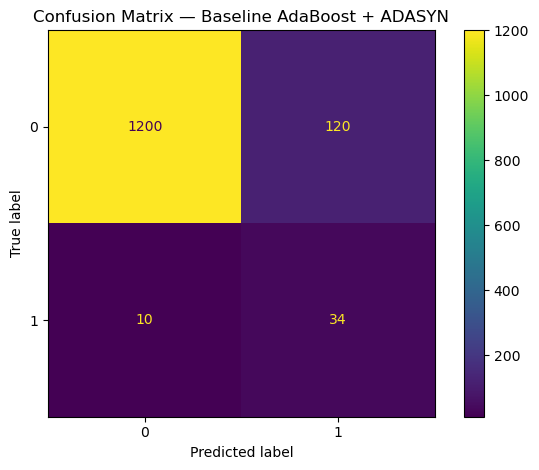

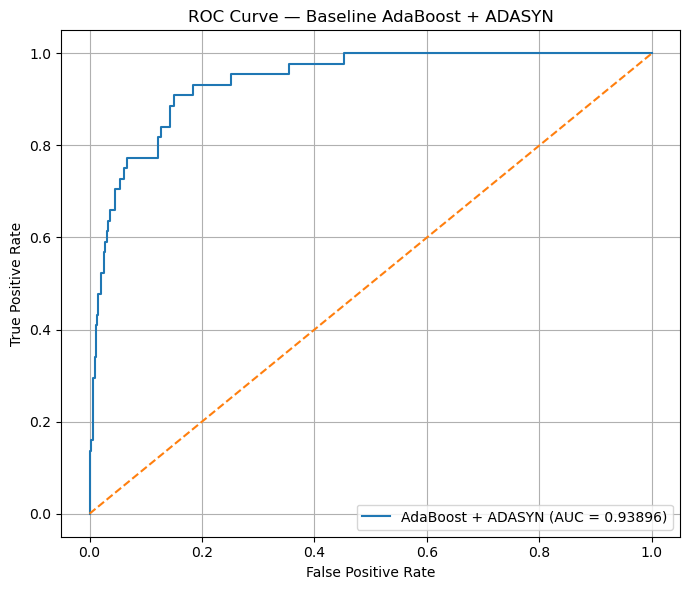

ROC AUC: 0.93896


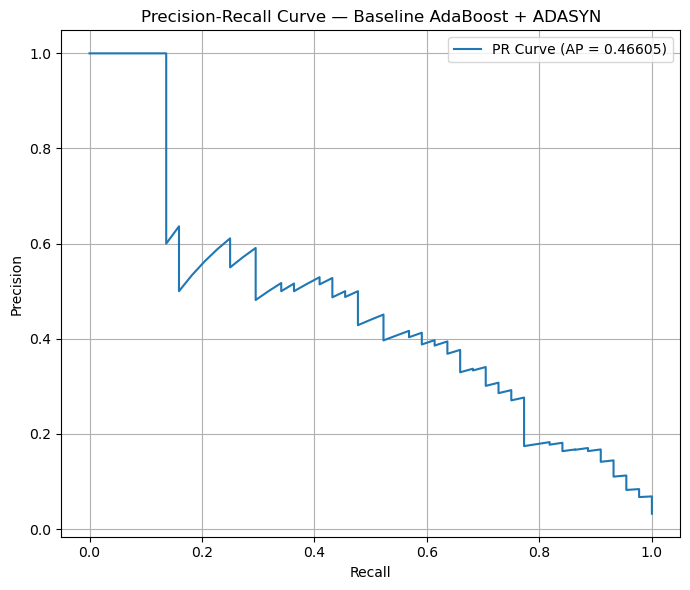

PRC AUC (Average Precision): 0.46605


In [33]:
#Vytvorenie pipeline s ADASYN a AdaBoost modelom
baseline_adasyn_ada = ImbPipeline(steps=[
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.1,
            random_state=42
        )
    )
])

#Trénovanie modelu na trénovacích dátach
baseline_adasyn_ada.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred3 = baseline_adasyn_ada.predict(X_test)

# Predikcia pravdepodobnosti pre triedu 1
y_proba3 = baseline_adasyn_ada.predict_proba(X_test)[:, 1]


#Výpis reportu klasifikácie
print("Baseline AdaBoost + ADASYN")
print(classification_report(y_test, y_pred3, digits=5))

#Matica zámen
cm = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline AdaBoost + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc3 = roc_auc_score(y_test, y_proba3)
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(fpr3, tpr3, label=f"AdaBoost + ADASYN (AUC = {roc_auc3:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline AdaBoost + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc3:.5f}")


#Precision-Recall krivka
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba3)
prc_auc3 = average_precision_score(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(recalls3, precisions3, label=f"PR Curve (AP = {prc_auc3:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline AdaBoost + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc3:.5f}")

### AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best params:
{'model__learning_rate': 0.03, 'model__n_estimators': 200, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.15, 'under__sampling_strategy': 0.1}
F1-score (CV): 0.4588

Threshold: 0.5097

Classification Report (AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9840    0.9758    0.9798      1320
           1     0.4182    0.5227    0.4646        44

    accuracy                         0.9611      1364
   macro avg     0.7011    0.7492    0.7222      1364
weighted avg     0.9657    0.9611    0.9632      1364


Confusion Matrix
[[1288   32]
 [  21   23]]


<Figure size 600x500 with 0 Axes>

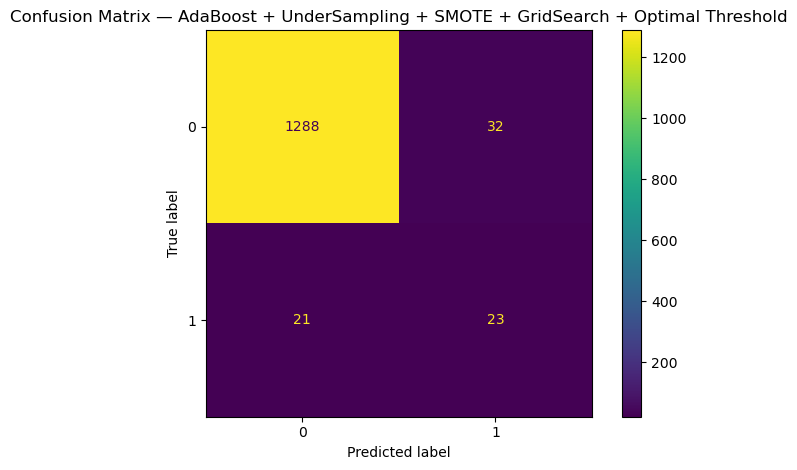

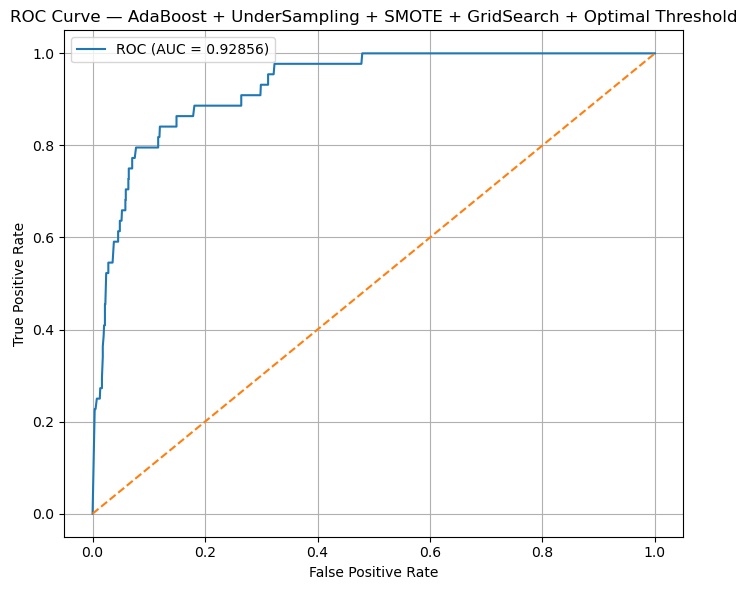

ROC AUC: 0.92856


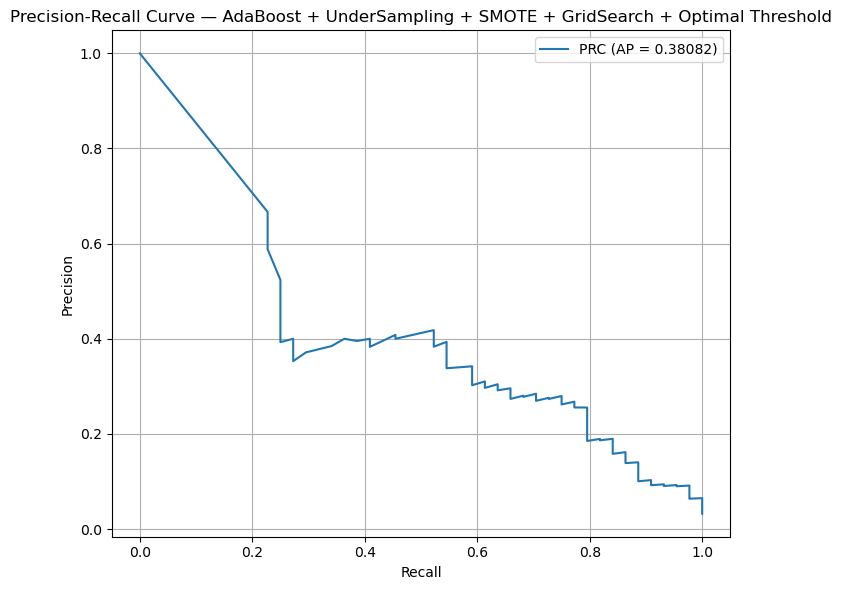

PRC AUC (Average Precision): 0.38082


In [44]:
#Vytvorenie pipeline s undersamplingom, SMOTE a AdaBoost modelom
pipe4 = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        AdaBoostClassifier(
            random_state=42,
            algorithm="SAMME"
        )
    )
])

#Definovanie rozsahu hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.08, 0.10],
    'smote__sampling_strategy': [0.15, 0.20, 0.25],
    'smote__k_neighbors': [3, 5],
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.03, 0.05, 0.1]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definovanie hodnotiacej metriky F1-score
scorer = make_scorer(f1_score, pos_label=1)

#Nastavenie GridSearchCV pre hľadanie najlepších parametrov
grid_search = GridSearchCV(
    estimator=pipe4,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

#Spustenie trénovania a hľadania najlepšieho modelu
grid_search.fit(X_train, y_train)

#Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

#Uloženie najlepšieho modelu
best_model4 = grid_search.best_estimator_

#Výpočet pravdepodobností pre triedu 1
probs = best_model4.predict_proba(X_test)[:, 1]

precisions4, recalls4, thresholds4 = precision_recall_curve(y_test, probs)

#Výpočet F1-score pre rôzne prahy
f1_scores4 = 2 * precisions4[:-1] * recalls4[:-1] / (precisions4[:-1] + recalls4[:-1] + 1e-9)

#Výber prahu s najvyšším F1-score
best_idx4 = np.argmax(f1_scores4)
best_threshold4 = thresholds4[best_idx4]
print(f"\nThreshold: {best_threshold4:.4f}")

#Predikcia tried podľa optimálneho prahu
y_pred4 = (probs >= best_threshold4).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred4, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred4)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc4 = roc_auc_score(y_test, probs)
fpr4, tpr4, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr4, tpr4, label=f"ROC (AUC = {roc_auc4:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc4:.5f}")


#Precision-Recall krivka
prc_auc4 = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls4, precisions4, label=f"PRC (AP = {prc_auc4:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc4:.5f}")

### AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params:
{'adasyn__n_neighbors': 5, 'adasyn__sampling_strategy': 0.25, 'model__learning_rate': 0.1, 'model__n_estimators': 300, 'under__sampling_strategy': 0.08}
F1-score (CV): 0.4489

Threshold: 0.5260

Classification Report (AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9847    0.9735    0.9790      1320
           1     0.4068    0.5455    0.4660        44

    accuracy                         0.9597      1364
   macro avg     0.6957    0.7595    0.7225      1364
weighted avg     0.9660    0.9597    0.9625      1364


Confusion Matrix
[[1285   35]
 [  20   24]]


<Figure size 600x500 with 0 Axes>

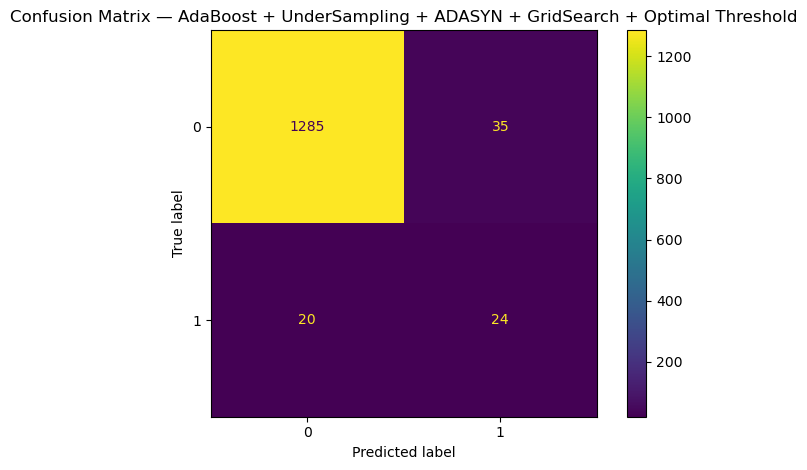

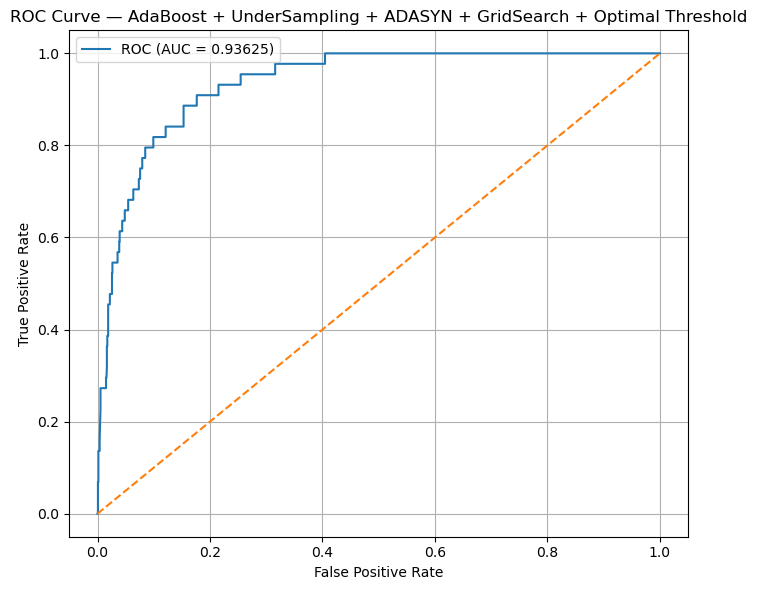

ROC AUC: 0.93625


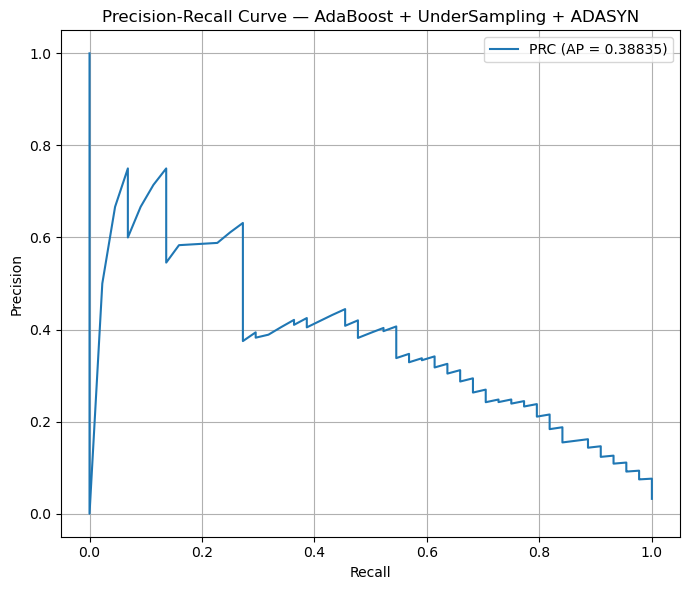

PRC AUC (Average Precision): 0.38835


In [49]:
#Vytvorenie pipeline s undersamplingom, ADASYN a AdaBoost modelom
pipe5 = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        AdaBoostClassifier(
            algorithm="SAMME",
            random_state=42
        )
    )
])

#Definovanie hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.05, 0.08],

    'adasyn__sampling_strategy': [0.25, 0.30, 0.35],
    'adasyn__n_neighbors': [3, 5],

    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.03, 0.05, 0.1]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nastavenie F1-score ako hodnotiacej metriky
scorer = make_scorer(f1_score, pos_label=1)

# Vytvorenie GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe5,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

# Trénovanie modelu a hľadanie najlepších parametrov
grid_search.fit(X_train, y_train)

# Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)

# Výpis najlepšieho F1-score z krížovej validácie
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

# Uloženie najlepšieho modelu
best_model = grid_search.best_estimator_

# Výpočet pravdepodobností pre triedu 1
probs = best_model.predict_proba(X_test)[:, 1]

# Výpočet hodnôt pre Precision-Recall krivku
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# Výpočet F1-score pre rôzne prahy
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

# Výber najlepšieho prahu podľa F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"\nThreshold: {best_threshold:.4f}")

# Predikcia tried podľa optimálneho prahu
y_pred5 = (probs >= best_threshold).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred5, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred5)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc5 = roc_auc_score(y_test, probs)
fpr5, tpr5, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr5, tpr5, label=f"ROC (AUC = {roc_auc5:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc5:.5f}")


#Precision-Recall krivka
prc_auc5 = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, label=f"PRC (AP = {prc_auc5:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — AdaBoost + UnderSampling + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc5:.5f}")

### Výsledky všetkých modelov ###

In [51]:
print("Baseline AdaBoost")
print(classification_report(y_test, y_pred1))

print("Baseline AdaBoost + SMOTE")
print(classification_report(y_test, y_pred2))

print("Baseline AdaBoost + ADASYN")
print(classification_report(y_test, y_pred3))

print("\nClassification Report (AdaBoost + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred4))

print("\nClassification Report (AdaBoost + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred5))

Baseline AdaBoost
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1320
           1       0.46      0.25      0.32        44

    accuracy                           0.97      1364
   macro avg       0.72      0.62      0.65      1364
weighted avg       0.96      0.97      0.96      1364

Baseline AdaBoost + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1320
           1       0.26      0.77      0.38        44

    accuracy                           0.92      1364
   macro avg       0.62      0.85      0.67      1364
weighted avg       0.97      0.92      0.94      1364

Baseline AdaBoost + ADASYN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1320
           1       0.22      0.77      0.34        44

    accuracy                           0.90      1364
   macro avg       0.61      0.84      0.65      1364
wei

### Permutation importance ###

                                              feature  importance
35                         Total debt/Total net worth    0.236364
9                Continuous interest rate (after tax)    0.236364
18            Persistent EPS in the Last Four Seasons    0.218182
85                         Net Income to Total Assets    0.204545
39                               Borrowing dependency    0.168182
13                Interest-bearing debt interest rate    0.086364
8         Non-industry income and expenditure/revenue    0.063636
67                  Retained Earnings to Total Assets    0.054545
33                                        Quick Ratio    0.036364
2    ROA(B) before interest and depreciation after...    0.022727


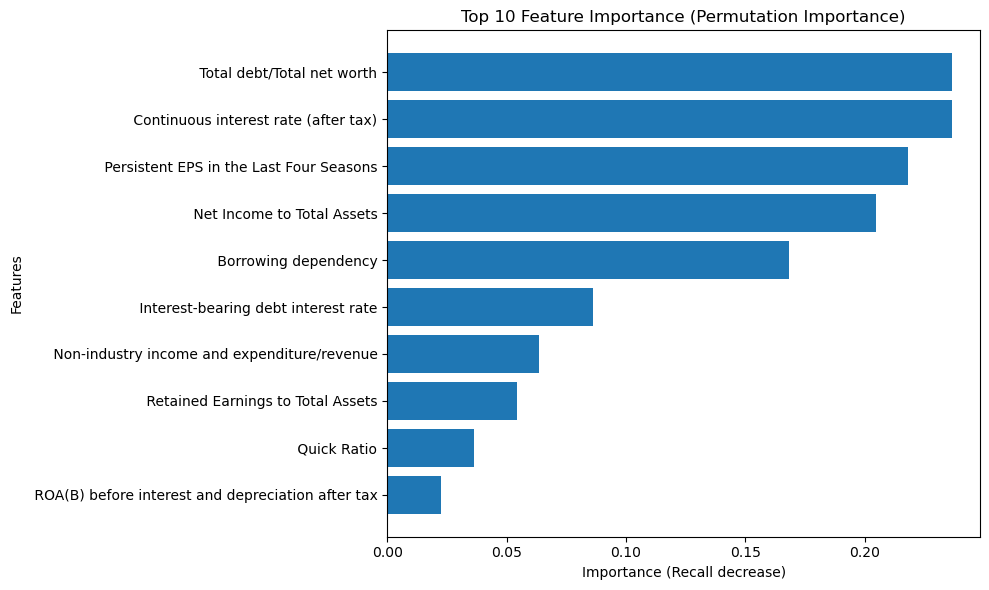

In [54]:
#Vytvorenie kópie testovacích dát
X_test_imp = X_test.copy()

#Výpočet permutation importance pre najlepší model
result = permutation_importance(
    best_model["model"],
    X_test_imp,
    y_test,
    scoring="recall",         
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

#Vytvorenie tabuľky s dôležitosťou premenných
importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

#Výpis 10 najdôležitejších premenných
print(importance_df.head(10))

#Výber 10 najdôležitejších premenných
top10 = importance_df.head(10)

#Vykreslenie grafu dôležitosti premenných
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Permutation Importance)")
plt.xlabel("Importance (Recall decrease)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

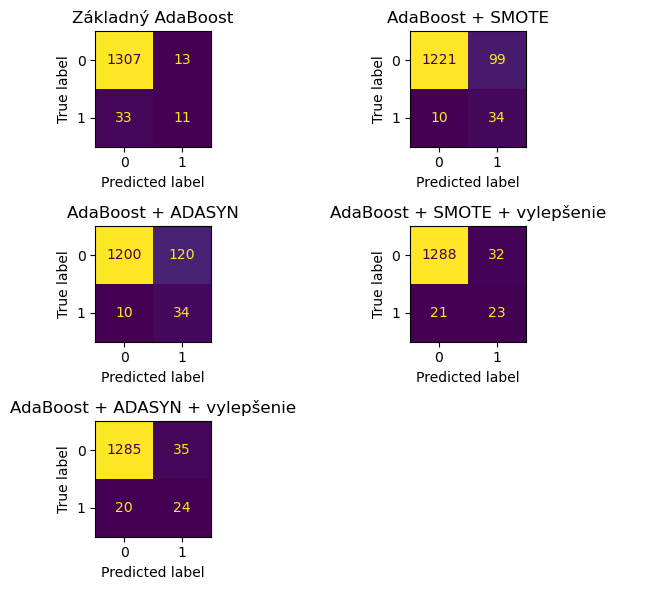

In [94]:
fig, axes = plt.subplots(3, 2, figsize=(7, 6))

cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Základný AdaBoost")

cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("AdaBoost + SMOTE")

cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("AdaBoost + ADASYN")

cm4 = confusion_matrix(y_test, y_pred4)
ConfusionMatrixDisplay(cm4).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("AdaBoost + SMOTE + vylepšenie")

cm5 = confusion_matrix(y_test, y_pred5)
ConfusionMatrixDisplay(cm5).plot(ax=axes[2, 0], colorbar=False)
axes[2, 0].set_title("AdaBoost + ADASYN + vylepšenie")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

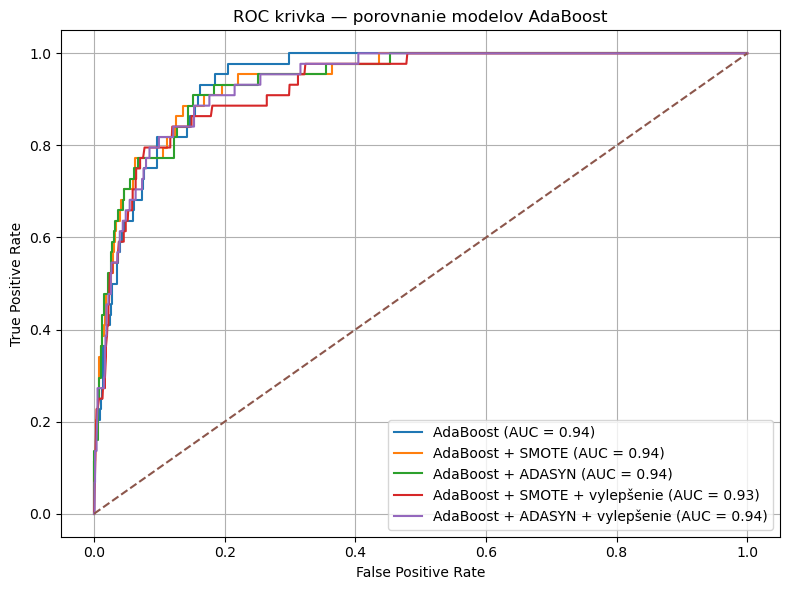

In [89]:
fpr1, tpr1, _ = roc_curve(y_test, y_proba1)
roc_auc1 = roc_auc_score(y_test, y_proba1)

fpr2, tpr2, _ = roc_curve(y_test, y_proba2)
roc_auc2 = roc_auc_score(y_test, y_proba2)

fpr3, tpr3, _ = roc_curve(y_test, y_proba3)
roc_auc3 = roc_auc_score(y_test, y_proba3)

probs4 = best_model4.predict_proba(X_test)[:, 1]
fpr4, tpr4, _ = roc_curve(y_test, probs4)
roc_auc4 = roc_auc_score(y_test, probs4)

probs5 = best_model.predict_proba(X_test)[:, 1]
fpr5, tpr5, _ = roc_curve(y_test, probs5)
roc_auc5 = roc_auc_score(y_test, probs5)

plt.figure(figsize=(8, 6))

plt.plot(fpr1, tpr1, label=f"AdaBoost (AUC = {roc_auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"AdaBoost + SMOTE (AUC = {roc_auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"AdaBoost + ADASYN (AUC = {roc_auc3:.2f})")
plt.plot(fpr4, tpr4, label=f"AdaBoost + SMOTE + vylepšenie (AUC = {roc_auc4:.2f})")
plt.plot(fpr5, tpr5, label=f"AdaBoost + ADASYN + vylepšenie (AUC = {roc_auc5:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka — porovnanie modelov AdaBoost")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

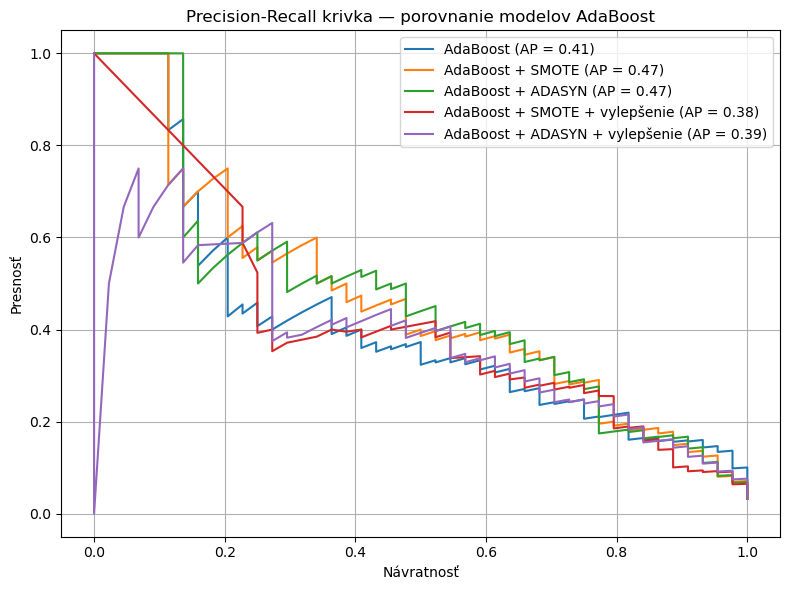

In [92]:
prec1, rec1, _ = precision_recall_curve(y_test, y_proba1)
ap1 = average_precision_score(y_test, y_proba1)

prec2, rec2, _ = precision_recall_curve(y_test, y_proba2)
ap2 = average_precision_score(y_test, y_proba2)

prec3, rec3, _ = precision_recall_curve(y_test, y_proba3)
ap3 = average_precision_score(y_test, y_proba3)

probs4 = best_model4.predict_proba(X_test)[:, 1]
prec4, rec4, _ = precision_recall_curve(y_test, probs4)
ap4 = average_precision_score(y_test, probs4)

probs5 = best_model.predict_proba(X_test)[:, 1]
prec5, rec5, _ = precision_recall_curve(y_test, probs5)
ap5 = average_precision_score(y_test, probs5)

plt.figure(figsize=(8, 6))

plt.plot(rec1, prec1, label=f"AdaBoost (AP = {ap1:.2f})")
plt.plot(rec2, prec2, label=f"AdaBoost + SMOTE (AP = {ap2:.2f})")
plt.plot(rec3, prec3, label=f"AdaBoost + ADASYN (AP = {ap3:.2f})")
plt.plot(rec4, prec4, label=f"AdaBoost + SMOTE + vylepšenie (AP = {ap4:.2f})")
plt.plot(rec5, prec5, label=f"AdaBoost + ADASYN + vylepšenie (AP = {ap5:.2f})")

plt.xlabel("Návratnosť")
plt.ylabel("Presnosť")
plt.title("Precision-Recall krivka — porovnanie modelov AdaBoost")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()